In [8]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Your color palette
COLORS = {
    'light_pink': '#F2B5B8',
    'pink':       '#E08EA4',
    'salmon':     '#DC6C6E',
    'apricot':    '#EB987A',
    'berry':      '#cc4a74',
    'purple':     '#9e169d',
}

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['grid.linestyle'] = '--'


In [9]:
def read_csv_safely(path: os.PathLike | str) -> pd.DataFrame:
    """Read a CSV log safely. Returns an empty DataFrame if missing or unreadable."""
    path = Path(path)
    if not path.exists():
        print(f'[Warn] File not found: {path}')
        return pd.DataFrame()
    try:
        df = pd.read_csv(path, on_bad_lines='skip')
        # Ensure numeric step if possible
        if 'step' in df.columns:
            df['step'] = pd.to_numeric(df['step'], errors='coerce')
            df = df.dropna(subset=['step']).sort_values('step')
        return df
    except Exception as e:
        print(f'[Error] Reading {path}: {e}')
        return pd.DataFrame()

def get_df_from_root_or_map(root_dir: os.PathLike | str | None, file_map: dict[str, str] | None, key: str) -> pd.DataFrame:
    """Load a dataframe either from ROOT_DIR/<key>/run.log (Option A) or from FILES[key] (Option B)."""
    if file_map is not None and key in file_map:
        return read_csv_safely(file_map[key])
    if root_dir is None:
        print(f'[Warn] No ROOT_DIR and no FILES entry for: {key}')
        return pd.DataFrame()
    return read_csv_safely(Path(root_dir) / key / 'run.log')

def require_columns(df: pd.DataFrame, cols: list[str], name: str) -> bool:
    missing = [c for c in cols if c not in df.columns]
    if missing:
        print(f'[Warn] Missing columns {missing} in {name}. Available columns: {list(df.columns)}')
        return False
    return True

In [10]:
def plot_policy_comparison(root_dir=None, file_map=None, *, pre_t=20000, deploy_t=20000, post_t=20000, save=True, show=True):
    """(i) Policy: Epsilon-Greedy vs TopK-Stochastic (curve of gTE_gap over time)."""
    df_eps  = get_df_from_root_or_map(root_dir, file_map, 'policy_epsgreedy')
    df_topk = get_df_from_root_or_map(root_dir, file_map, 'policy_topkstochastic')

    if df_eps.empty or df_topk.empty:
        print('Skipping Policy Plot (missing data)')
        return None
    if not (require_columns(df_eps,  ['step', 'gCal_max'], 'policy_epsgreedy') and
            require_columns(df_topk, ['step', 'gCal_max'], 'policy_topkstochastic')):
        print('Skipping Policy Plot (missing required columns)')
        return None

    fig = plt.figure(figsize=(8, 5))
    plt.plot(df_eps['step'], df_eps['gCal_max'], label='Epsilon-Greedy', color=COLORS['apricot'], linewidth=2.5, linestyle='--')
    plt.plot(df_topk['step'], df_topk['gCal_max'], label='TopK-Stochastic', color=COLORS['purple'], linewidth=2.5)

    # Phase boundaries
    x1 = pre_t
    x2 = pre_t + deploy_t
    for x_line in [x1, x2]:
        plt.axvline(x=x_line, color='gray', linestyle=':', alpha=0.5)

    # Phase labels (placed near top of y-range)
    y_min, y_max = plt.ylim()
    y_text = y_min + 0.9 * (y_max - y_min)
    plt.text(pre_t * 0.5, y_text, 'Pre', ha='center', color='gray')
    plt.text(pre_t + deploy_t * 0.5, y_text, 'Deploy', ha='center', color='gray')
    plt.text(pre_t + deploy_t + post_t * 0.5, y_text, 'Post', ha='center', color='gray')

    plt.xlabel('Time Step')
    plt.ylabel('Fairness Gap (gCal_max)')
    plt.title('(i) Ablation: Exploration Policy Stability')
    plt.legend()
    plt.tight_layout()

    if save:
        out = Path(root_dir) / 'fig_ablation_policy.png' if root_dir is not None else Path('fig_ablation_policy.png')
        plt.savefig(out, dpi=300)
        print(f'Generated: {out}')
    if show:
        plt.show()
    plt.close()
    return fig

def plot_coverage_comparison(root_dir=None, file_map=None, *, save=True, show=True):
    """(ii) Coverage: Off vs 0.01 vs 0.05 (bar chart of final gMin)."""
    tags = ['covexp_off', 'covexp_001', 'covexp_005']
    labels = ['Off', 'Target 0.01', 'Target 0.05']
    values = []

    for tag in tags:
        df = get_df_from_root_or_map(root_dir, file_map, tag)
        if not df.empty and 'gMin' in df.columns:
            values.append(float(df['gMin'].iloc[-1]))
        else:
            values.append(0.0)

    fig = plt.figure(figsize=(6, 5))
    bars = plt.bar(labels, values, color=[COLORS['salmon'], COLORS['berry'], COLORS['purple']], width=0.6)

    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, height, f'{height:.4f}', ha='center', va='bottom')

    plt.ylabel('Minimum Effect (gMin)')
    plt.title('(ii) Ablation: Coverage-driven Exploration')
    plt.tight_layout()

    if save:
        out = Path(root_dir) / 'fig_ablation_coverage.png' if root_dir is not None else Path('fig_ablation_coverage.png')
        plt.savefig(out, dpi=300)
        print(f'Generated: {out}')
    if show:
        plt.show()
    plt.close()
    return fig

def plot_attribute_comparison(root_dir=None, file_map=None, *, save=True, show=True):
    """(vii) Attribute: Node Mod vs Node Degree (bar chart of final gTE_gap)."""
    df_mod = get_df_from_root_or_map(root_dir, file_map, 'group_nodemod')
    df_deg = get_df_from_root_or_map(root_dir, file_map, 'group_nodedegree')

    val_mod = float(df_mod['gCal_max'].iloc[-1]) if (not df_mod.empty and 'gCal_max' in df_mod.columns) else 0.0
    val_deg = float(df_deg['gCal_max'].iloc[-1]) if (not df_deg.empty and 'gCal_max' in df_deg.columns) else 0.0

    labels = ['Random (Node Mod)', 'Structural (Node Degree)']
    values = [val_mod, val_deg]

    fig = plt.figure(figsize=(5, 5))
    plt.bar(labels, values, color=[COLORS['light_pink'], COLORS['berry']], alpha=0.9, width=0.5)
    for i, v in enumerate(values):
        plt.text(i, v, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

    plt.ylabel('Fairness Gap (gTE_gap)')
    plt.title('(vii) Sensitivity: Group Attribute Construction')
    plt.tight_layout()

    if save:
        out = Path(root_dir) / 'fig_ablation_attribute.png' if root_dir is not None else Path('fig_ablation_attribute.png')
        plt.savefig(out, dpi=300)
        print(f'Generated: {out}')
    if show:
        plt.show()
    plt.close()
    return fig

def make_all_plots(root_dir=None, file_map=None, *, pre_t=20000, deploy_t=20000, post_t=20000, save=True, show=True):
    _ = plot_policy_comparison(root_dir, file_map, pre_t=pre_t, deploy_t=deploy_t, post_t=post_t, save=save, show=show)
    _ = plot_coverage_comparison(root_dir, file_map, save=save, show=show)
    _ = plot_attribute_comparison(root_dir, file_map, save=save, show=show)

Generated: fig_ablation_policy.png


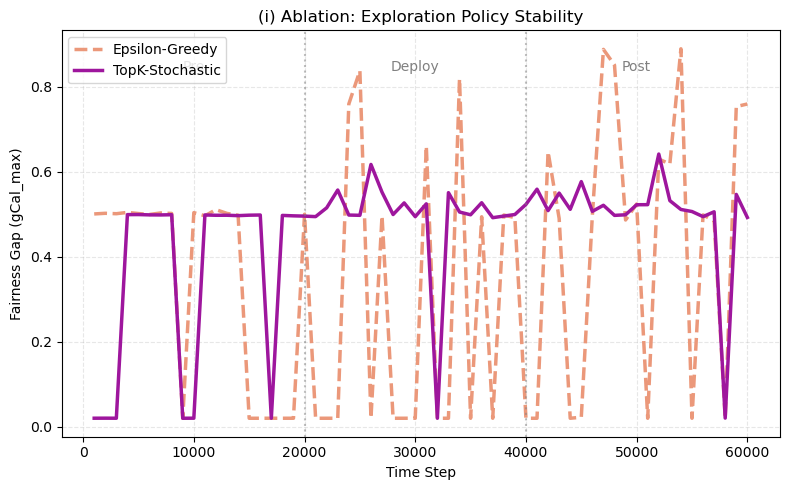

Generated: fig_ablation_coverage.png


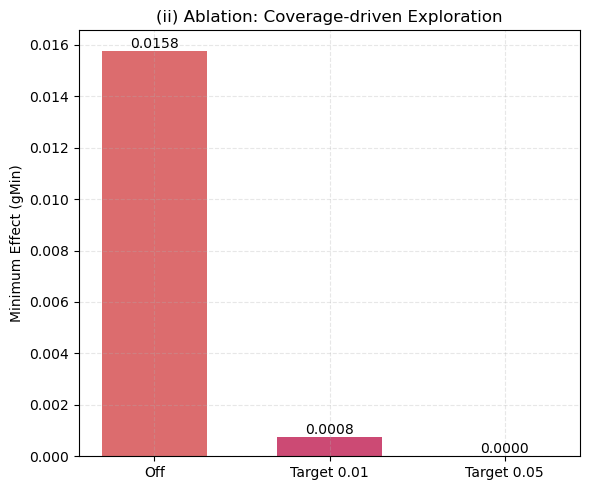

Generated: fig_ablation_attribute.png


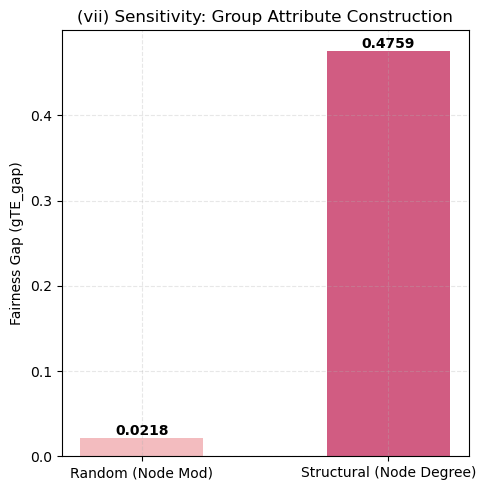

In [14]:
# =========================
# CONFIG
# =========================

# Option A: directory that contains the ablation subfolders shown above
ROOT_DIR = None  # e.g. '/path/to/ablation_out'

# Option B: direct file mapping (set ROOT_DIR=None to use this)
#FILES = None
FILES = {'covexp_off':'/data1/shengen/fairlink/out/ablations_wiki_parallel/covexp_off/opp_copf_metrics.csv',
          'covexp_001':'/data1/shengen/fairlink/out/ablations_wiki_parallel/covexp_001/opp_copf_metrics.csv',
            'covexp_005':'/data1/shengen/fairlink/out/ablations_wiki_parallel/covexp_005/opp_copf_metrics.csv',
                'group_nodemod':'/data1/shengen/fairlink/out/ablations_wiki_parallel/group_nodemod/opp_copf_metrics.csv',
                  'group_nodedegree':'/data1/shengen/fairlink/out/ablations_wiki_parallel/group_nodedegree/opp_copf_metrics.csv',
                      'policy_epsgreedy': '/data1/shengen/fairlink/out/ablations_wiki_parallel/policy_epsgreedy/opp_copf_metrics.csv',
                      'policy_topkstochastic': '/data1/shengen/fairlink/out/ablations_wiki_parallel/policy_topkstochastic/opp_copf_metrics.csv'
}

#     'group_nodemod':         '/path/to/group_nodemod_run.log',
#     'group_nodedegree':      '/path/to/group_nodedegree_run.log',
# }

PRE_T = 20000
DEPLOY_T = 20000
POST_T = 20000

# =========================
# RUN
# =========================
make_all_plots(ROOT_DIR, FILES, pre_t=PRE_T, deploy_t=DEPLOY_T, post_t=POST_T, save=True, show=True)
